In [9]:
import kagglehub
import os
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.options.plotting.backend = "plotly"

path = kagglehub.dataset_download("cactus3/basicshapes")

classes, paths = [], []

for dirname, _, filenames in os.walk(path):
    for filename in filenames:
        if filename.endswith('.png'):
            classes.append(dirname.split('\\')[-1])
            paths.append(os.path.join(dirname, filename))

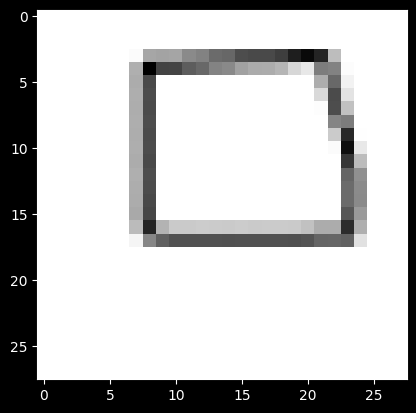

In [7]:
def get_vector_from_path(path):
    img = mpimg.imread(path)
    return np.einsum('ijk->ij', img / 3).reshape(28 * 28)

plt.imshow(get_vector_from_path(paths[200]).reshape(28, 28), cmap='gray')

In [29]:
data = []
for i, shape in enumerate(classes):
    data.append([shape] + get_vector_from_path(paths[i]).tolist())

df = pd.DataFrame(data, columns = ["shape"] + [f"pixel_{i//28}_{i%28}" for i in range(28*28)])
df.head()

,shape,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_0_8,...,pixel_27_18,pixel_27_19,pixel_27_20,pixel_27_21,pixel_27_22,pixel_27_23,pixel_27_24,pixel_27_25,pixel_27_26,pixel_27_27
0,circles,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,circles,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,circles,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,circles,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,circles,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [43]:
import plotly.express as px

px.imshow(df.iloc[200, 1:].values.reshape(28, 28), color_continuous_scale="gray")

In [44]:
df.to_csv("shapes.csv", index=False)